# Test ABL with K-epsilon model

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', './',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_keps as SANDwake3D

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
#?solve_ivp

## Set mesh and BC's 

In [3]:
# Set up mesh and BL parameters
Uinf = 1.0
nu   = 1.5E-5 # m^2/s

# y-z mesh 
#zmin = 1
#zmax = 120
#Nz   = int((zmax-zmin)/1.0+1)
zmin = 4
zmax = 200
Nz   = int((zmax-zmin)/4.0+1)
zvec = np.linspace(zmin,zmax,Nz)

Ny=51
ymax = 100
yvec = np.linspace(-ymax,ymax,Ny)

# x grid
xvecplot = [0, 10]

In [4]:
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(f'dy = {dy}')
print(f'dz = {dz}')

dy = 4.0
dz = 4.0


In [5]:
# Set ABL parameters
ABLparam = {
    'ustar' : 0.4, #0.575652,
    'L' : float('inf'),
    'kappa' : 0.42,
    'rho' : 1.225,
    'z0' : 0.15,
    'Cmu' : 5.48**(-2),
}

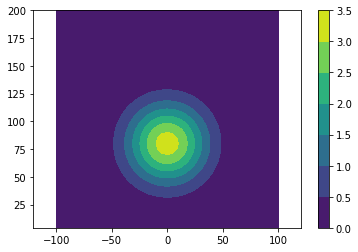

In [6]:
turbhh = 80
turbR  = 50
wakedef= 3.25
wakeU  = wakedef*np.exp(-2.0*(ym**2 + (zm-turbhh)**2)/turbR**2)
plt.contourf(ym, zm, wakeU)
plt.axis('equal')
plt.colorbar()

In [7]:
Uinit  = np.zeros((Ny, Nz))
Vinit  = np.zeros((Ny, Nz))
Winit  = np.zeros((Ny, Nz))
Kinit  = np.zeros((Ny, Nz))
EPSinit= np.zeros((Ny, Nz))

for iz, z in enumerate(zvec):
    Uinit[:, iz] = SANDwake3D.init_U_ABL(z,ABLparam)
    Vinit[:, iz] = 0.0
    Winit[:, iz] = 0.0
    Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,ABLparam)*0.3 #0.2
    EPSinit[:, iz] = SANDwake3D.init_e_ABL(z,ABLparam)*0.1
    
Uinit = Uinit - wakeU
#for iy, y in enumerate(yvec):
#    Kinit[iy,:]   = SANDwake3D.set_k_init(zvec, dz, Uinit[0,:],ABLparam,k_factor=0.1)
#    EPSinit[iy,:] = SANDwake3D.set_e_init(zvec, dz, Uinit[0,:], Kinit[0,:], ABLparam)
Kinit[:,0] = Kinit[:,1]
Kinit[:,-2] = Kinit[:,-1]
#EPSinit[:,0] = EPSinit[:,1]
#EPSinit[:,-2] = EPSinit[:,-1]

phiinit = {}
phiinit['u'] = Uinit
phiinit['v'] = Vinit
phiinit['w'] = Winit
phiinit['k'] = Kinit
phiinit['eps'] = EPSinit

(0.0, 200.0)

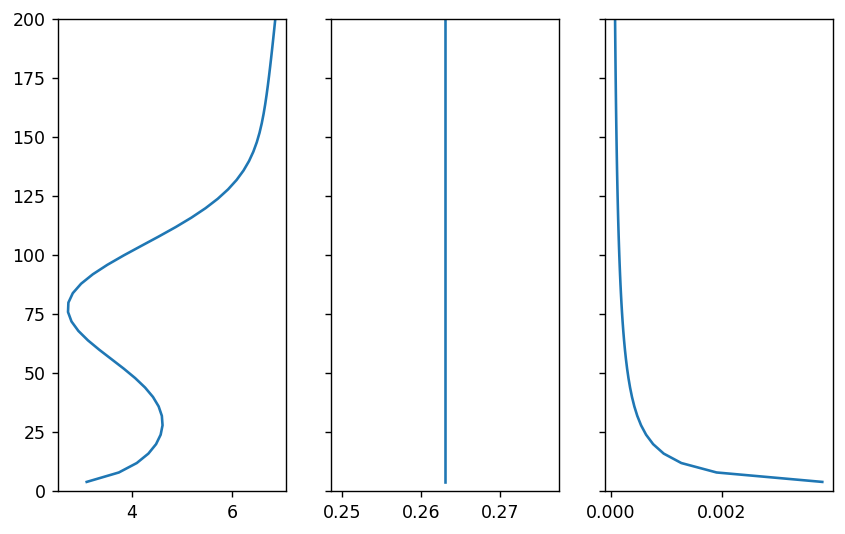

In [8]:
fig, axs = plt.subplots(1,3, sharey=True, dpi=125, figsize=(8,5))
axs[0].plot(Uinit[Ny//2,:], zvec)
axs[1].plot(Kinit[Ny//2,:], zvec)
axs[2].plot(EPSinit[Ny//2,:], zvec)
axs[0].set_ylim([0, zmax])

In [9]:
# Set boundary conditions
ubc = {}
ubc['ylo'] = {'type':'neumann', 'value':0.0}
ubc['yhi'] = {'type':'neumann', 'value':0.0}
ubc['zlo'] = {'type':'dirichlet', 'value':Uinit[0,0]}
ubc['zhi'] = {'type':'dirichlet', 'value':Uinit[0,-1]}

vbc = {}
vbc['ylo'] = {'type':'dirichlet', 'value':0.0}
vbc['yhi'] = {'type':'dirichlet', 'value':0.0}
vbc['zlo'] = {'type':'dirichlet', 'value':0.0}
vbc['zhi'] = {'type':'dirichlet', 'value':0.0}

wbc = {}
wbc['ylo'] = {'type':'neumann', 'value':0.0}
wbc['yhi'] = {'type':'neumann', 'value':0.0}
wbc['zlo'] = {'type':'dirichlet', 'value':0.0}
wbc['zhi'] = {'type':'neumann', 'value':0.0}

kbc = {}
kbc['ylo'] = {'type':'neumann', 'value':0.0}
kbc['yhi'] = {'type':'neumann', 'value':0.0}
kbc['zlo'] = {'type':'dirichlet', 'value':Kinit[0,0]}
kbc['zhi'] = {'type':'neumann', 'value':0.0}

epsbc = {}
epsbc['ylo'] = {'type':'neumann', 'value':0.0}
epsbc['yhi'] = {'type':'neumann', 'value':0.0}
epsbc['zlo'] = {'type':'dirichlet', 'value':EPSinit[0,0]}
epsbc['zhi'] = {'type':'neumann', 'value':0.0}

allbc = {'u':ubc, 'v':vbc, 'w':wbc, 'k':kbc, 'eps':epsbc}

In [10]:
# Set parameters
params = {
    'nu' : nu,
    'Cmu' : 5.48**(-2),
    #'C_mu' : 0.01,
    'C1eps' : 1.76,
    'C2eps' : 1.92,
    'C3eps' : 0.033,
    'sigmak' : 1.0,
    'sigmaeps' : 1.3,
}
#params['nu']       = nu
#params['Cmu']      = 0.0
#params['C1eps']    = 0.0
#params['C2eps']    = 0.0
#params['C3eps']    = 0.0
#params['sigmak']   = 1.0
#params['sigmaeps'] = 1.0

In [11]:
xvecplot=[0, 50, 100]
dx  = 25
#xvec = [0, 10, 20, 30, 40]
xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec = np.arange(xvecplot[0], xvecplot[0]+dx+1.0E-6, dx)

#xvec = xvecplot
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, allbc, SANDwake3D.keps_eqns, 
                             advanceSys=SANDwake3D.advanceSystemKEPS,
                             verbose=True, maxiter=50, tol=1.0E-4)

x = 25.0 dx = 25.0
0 {'u': 5.960458495297289, 'w': 0.0, 'k': 6.749168451984097, 'eps': 0.001586493381080646, 'v': 0.0}
1 {'u': 7.384087060102798, 'w': 0.0, 'k': 9.215556226498576, 'eps': 0.0005164045201636591, 'v': 14.997268351754737}
2 {'u': 7.878523200988893, 'w': 0.0, 'k': 9.12520195293477, 'eps': 0.0002775459503352382, 'v': 19.792820267516465}
3 {'u': 6.376227446543906, 'w': 0.0, 'k': 6.027924383435433, 'eps': 0.00025037035475238006, 'v': 27.528660693272396}
4 {'u': 4.099905919817373, 'w': 0.0, 'k': 4.668710804739829, 'eps': 0.00018681389796018006, 'v': 20.363613886959246}
5 {'u': 3.0582205114661707, 'w': 0.0, 'k': 6.420764007570181, 'eps': 0.00016076126520795834, 'v': 9.898332205751824}
6 {'u': 4.02218847375207, 'w': 0.0, 'k': 5.007634521403525, 'eps': 0.00019618776813854752, 'v': 11.103983025591472}
7 {'u': 2.9881737781215314, 'w': 0.0, 'k': 2.2047543658778808, 'eps': 0.00015493236013231607, 'v': 13.270106947792547}
8 {'u': 1.335768172299743, 'w': 0.0, 'k': 0.4375462536368088, 'e

(4.0, 200.0)

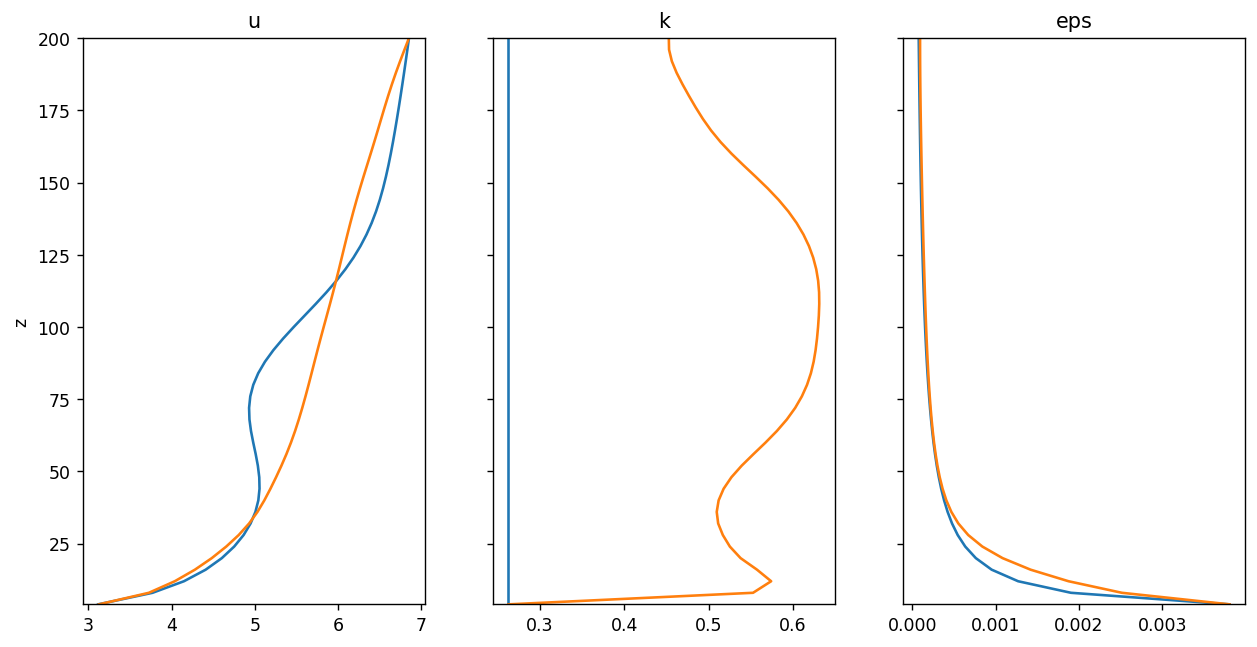

In [12]:
plotvars=['u', 'k', 'eps']
fig, axs = plt.subplots(1,len(plotvars),figsize=(12,6), dpi=125, sharey=True)
for iv, v in enumerate(plotvars):
    axs[iv].plot(np.mean(phi[v][0,:,:], axis=0), zvec,)
    axs[iv].plot(np.mean(phi[v][-1,:,:], axis=0), zvec,)
    axs[iv].set_title(v)
axs[0].set_ylabel('z')
axs[0].set_ylim([zmin, zmax])

(-100.0, 100.0, 4.0, 200.0)

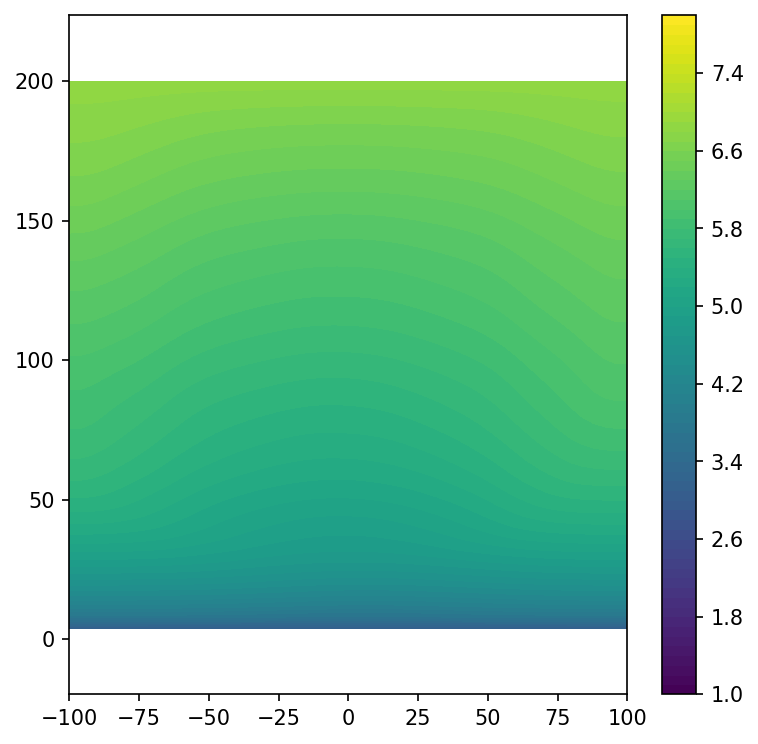

In [15]:
plt.figure(figsize=(6,6), dpi=150)
plt.contourf(ym, zm, phi['u'][-1,:,:], levels=np.linspace(1,8,71))
#plt.contourf(ym, zm, phi['v'][-1,:,:], levels=101)
plt.colorbar()
plt.axis('equal')

In [14]:
xvec

array([  0.,  25.,  50.,  75., 100.])